### **Introduction**

This is a Data Science project intended to further polish my skills as a future Machine Learning Engineer. In this project I will practice creating and Assessing the Linear Regression model I have built, using Statistics knowledge as well as detailed Statistical and Logical approaches to enhance Model Efficiency in the Prediction of Californian House Prices using the [California Housing Price dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices).

In this Multiple Linear Regression Analysis steps will be followed as below.

1. Collection of data
2. Cleaning and Preproccessing Data
3. Checking if Regression model follows the Preliminary Assumptions
4. Final Validation and Interpretation


### **Importing Libraries**

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.compat import lzip
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


pd.options.display.float_format = '{:,.3f}'.format


### **Importing data**

In [240]:
df = pd.read_csv("data/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,"452,600.000",NEAR BAY
1,-122.220,37.860,21.000,"7,099.000","1,106.000","2,401.000","1,138.000",8.301,"358,500.000",NEAR BAY
2,-122.240,37.850,52.000,"1,467.000",190.000,496.000,177.000,7.257,"352,100.000",NEAR BAY
3,-122.250,37.850,52.000,"1,274.000",235.000,558.000,219.000,5.643,"341,300.000",NEAR BAY
4,-122.250,37.850,52.000,"1,627.000",280.000,565.000,259.000,3.846,"342,200.000",NEAR BAY


### **Exploratory Data Analysis (EDA) and Data Cleaning**

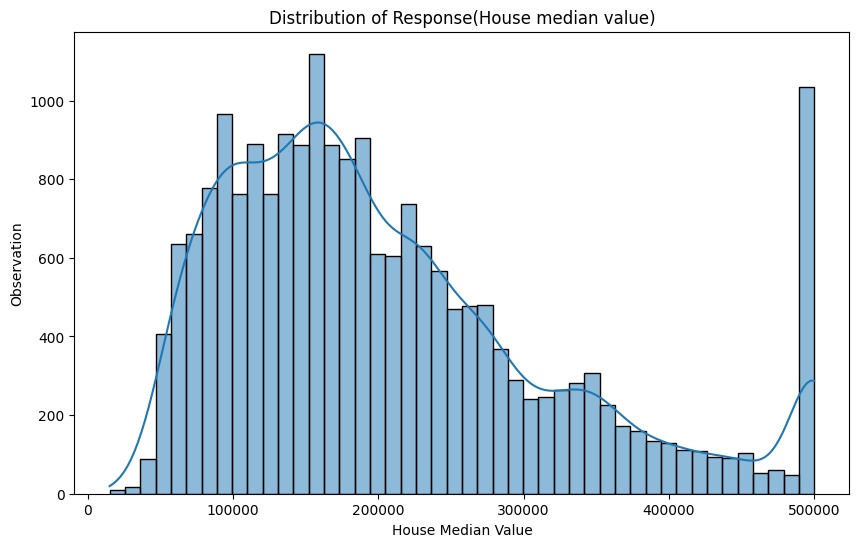

In [241]:
#looking at our data's distribution briefly
plt.figure(figsize=(10,6))
sns.histplot(df["median_house_value"],kde = True)
plt.title("Distribution of Response(House median value)")
plt.xlabel("House Median Value")
plt.ylabel("Observation")
plt.show()

** As we can see there are clear outliers, but we will access this later in our Model Adequacy Checking

In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Notice that total_bedrooms has missing values with only 20433 non-null instead of 20640 we will then check the exact number and percentage of missing values to see if it is significant enough to drop the variable (toatl_bedrooms).

In [243]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [244]:
(df.isna().sum()/len(df))*100

longitude            0.000
latitude             0.000
housing_median_age   0.000
total_rooms          0.000
total_bedrooms       1.003
population           0.000
households           0.000
median_income        0.000
median_house_value   0.000
ocean_proximity      0.000
dtype: float64

at a 1.0029 percent, missing vals arent significant enough to drop entire variable so we drop rows instead

In [245]:
df.shape

(20640, 10)

In [246]:
df = df.dropna()
df.shape

(20433, 10)

although unnecessary for Machine learning but it is best pratice in Data cleaning to change float data types that shouldnt be, to integers

In [247]:
cols = df.columns[2:7] #housing_median_age until households
df[cols] = df[cols].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  int64  
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.7+ MB


### **One-Hot-Encoding for "ocean_proximity" variable**

To prevent Multicollinearity caused by creating dummy variables (so called the "dummy trap") we must drop at least one of the created dummy variables

In [248]:
ocean_proximity_dummies = pd.get_dummies(df["ocean_proximity"],"ocean_prox",drop_first=True)
ocean_proximity_dummies.head()

,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,False,False,True,False
1,False,False,True,False
2,False,False,True,False
3,False,False,True,False
4,False,False,True,False


In [249]:
ocean_proximity_dummies = ocean_proximity_dummies.astype(int) # change from bool to int
ocean_proximity_dummies.head()

,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


In [250]:
df = df.drop(df.columns[-1], axis=1) #dropping original ocean_proximity variable
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.230,37.880,41,880,129,322,126,8.325,"452,600.000"
1,-122.220,37.860,21,7099,1106,2401,1138,8.301,"358,500.000"
2,-122.240,37.850,52,1467,190,496,177,7.257,"352,100.000"
3,-122.250,37.850,52,1274,235,558,219,5.643,"341,300.000"
4,-122.250,37.850,52,1627,280,565,259,3.846,"342,200.000"
...,...,...,...,...,...,...,...,...,...
20635,-121.090,39.480,25,1665,374,845,330,1.560,"78,100.000"
20636,-121.210,39.490,18,697,150,356,114,2.557,"77,100.000"
20637,-121.220,39.430,17,2254,485,1007,433,1.700,"92,300.000"
20638,-121.320,39.430,18,1860,409,741,349,1.867,"84,700.000"


In [251]:
#concatonating dummy variables with main dataframe
df = pd.concat([df,ocean_proximity_dummies],axis=1)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR BAY,ocean_prox_NEAR OCEAN
0,-122.230,37.880,41,880,129,322,126,8.325,"452,600.000",0,0,1,0
1,-122.220,37.860,21,7099,1106,2401,1138,8.301,"358,500.000",0,0,1,0
2,-122.240,37.850,52,1467,190,496,177,7.257,"352,100.000",0,0,1,0
3,-122.250,37.850,52,1274,235,558,219,5.643,"341,300.000",0,0,1,0
4,-122.250,37.850,52,1627,280,565,259,3.846,"342,200.000",0,0,1,0


### **Creating Model and Assessing Model Assumptions**

In the multiple Linear Regression model there are 4 main Preliminary assumptions

1. **Multicollinearity**: *Independent variables(Xi) should NOT be highly correlated with each other.*
2. **Linearity**: *Relationship between predictors(Xi) and Response(Yi) are linear.*
3. **Independence**: *Residuals/errors are independent of each other with no correlation.*
4. **Homoscedasticity & Normality**: *Residuals have a normal distribution with mean of 0 and constant variance. *

Since our Dependent variables are known we will start by checking if our dependent variables have **Multicollinearity (Assumption 1)**

### **Assumption 1: No Multicollinearity**

<function matplotlib.pyplot.show(close=None, block=None)>

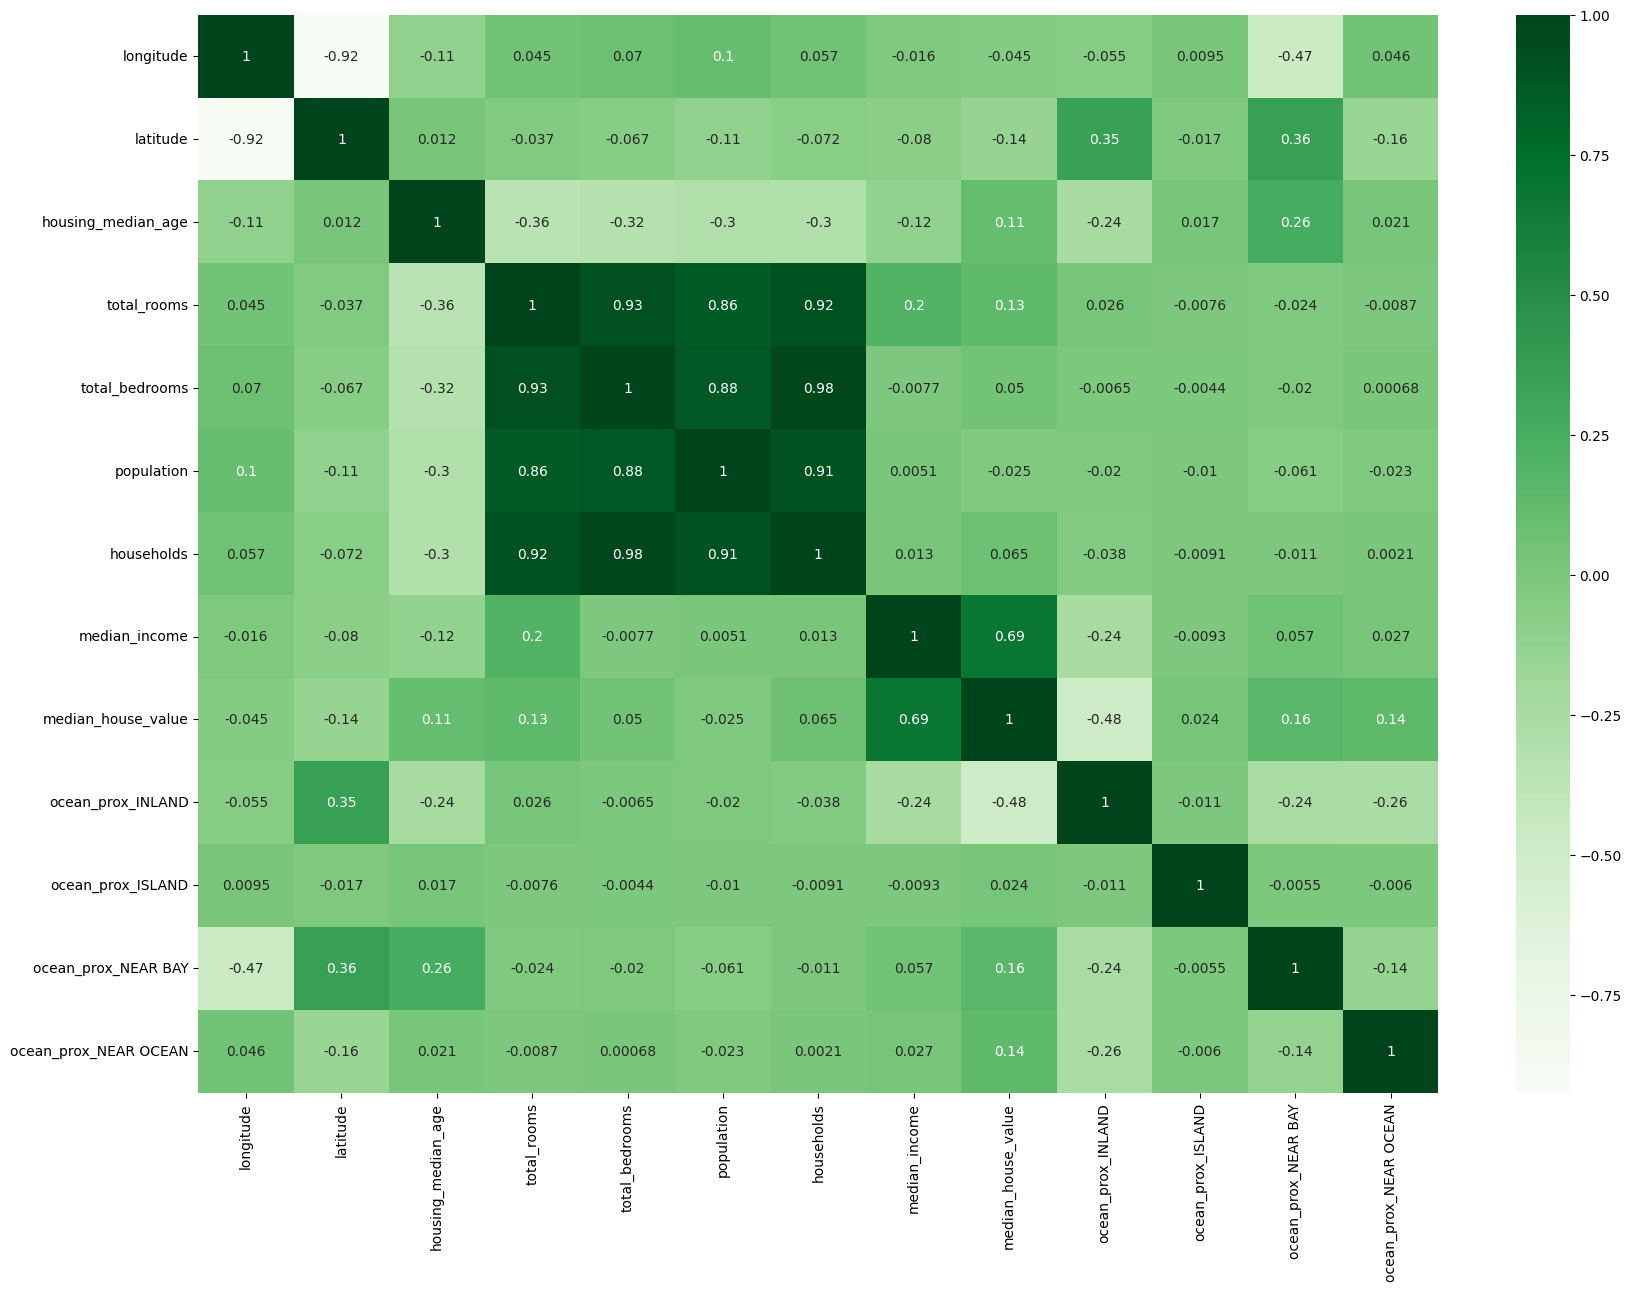

In [252]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(20,14))
sns.heatmap(corr,annot=True,cmap="Greens")
plt.show

As we can see from the correlation heatmap there is multicollinearity occurring within 6 noticable variables: longtitude, latitude, total_bedrooms, total rooms, households, population in order to decide which column to drop we check the Variance Inflation Factor(VIF) which is a method used to determine a variables multicollinearity parellel with their respective R squared values.

In [253]:

#adding a function to get VIF table with R squared to observe Multicollinearity


def get_VIF_table(df, target):
    VIF = pd.DataFrame()
    X = df.select_dtypes(include="number")
    X = X.drop(columns=[target])
    X = sm.add_constant(X) # adding like a "1" to our X matrix to get beta_0
    VIF["Variables"] = X.columns
    VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    VIF["R_squared"] = [ None if col == "const" else df[col].corr(df[target])**2 for col in X.columns]
    return VIF


In [254]:
get_VIF_table(df,"median_house_value")

,Variables,VIF,R_squared
0,const,"33,578.822",NaN
1,longitude,18.091,0.002
2,latitude,19.969,0.021
3,housing_median_age,1.324,0.011
4,total_rooms,12.966,0.018
5,total_bedrooms,36.310,0.002
6,population,6.446,0.001
7,households,35.173,0.004
8,median_income,1.786,0.474
9,ocean_prox_INLAND,2.860,0.235


In the VIF table we say that a variable has multicollinearity if the VIF > 10 , since total_bedrooms has a significant VIF (>10) and a low Coefficient correlation(R_squared) we drop the variable and see how the VIF table changes

In [255]:
df = df.drop(columns=["total_bedrooms"])
get_VIF_table(df,"median_house_value")

,Variables,VIF,R_squared
0,const,"33,069.230",NaN
1,longitude,17.881,0.002
2,latitude,19.842,0.021
3,housing_median_age,1.319,0.011
4,total_rooms,9.754,0.018
5,population,6.018,0.001
6,households,11.828,0.004
7,median_income,1.568,0.474
8,ocean_prox_INLAND,2.844,0.235
9,ocean_prox_ISLAND,1.002,0.001


The deletion of the "total_bedrooms" variable has significantly affected the VIF of other Variables. Variables that appear to have a high VIF are "latitude", "longtitude", and "households". 

We are going to be keeping Latitude and Longtitude Variables because they're high VIF mostly comes from correlation between them,not to mention that they are also meaningful geographical variables(we might cluster using K-means if this hurts our model). As for households, population, and total_rooms we should use Feature engineering to reduce these varibales into 2 variables: population_per_household and total_rooms_per_household, and see if they have a high VIF, if not we keep them.

In [256]:
df["total_rooms_per_households"] = df["total_rooms"] / df["households"]
df["population_per_household"] = df["population"] / df["households"]

df = df.drop(columns=["total_rooms", "households", "population"])
get_VIF_table(df,"median_house_value")

,Variables,VIF,R_squared
0,const,"33,896.393",NaN
1,longitude,18.220,0.002
2,latitude,20.197,0.021
3,housing_median_age,1.165,0.011
4,median_income,1.321,0.474
5,ocean_prox_INLAND,2.809,0.235
6,ocean_prox_ISLAND,1.001,0.001
7,ocean_prox_NEAR BAY,1.546,0.026
8,ocean_prox_NEAR OCEAN,1.183,0.020
9,total_rooms_per_households,1.255,0.023


The variables now have little to no Multicollinearity, successfully satisfying the 1st Assumption: No Multicollinearity

Next we create our model and then check the rest of the assumtions.

### **Splitting and Training Dataset**

Normally in Machine learning we would split dataset into train test and validation, but for Multiple Linear Regression Analysis since they're aren't any hyperparameters to tune we will be splitting into training and testing. Chosing size percentage of training and testing data are based on the goal, size of data, and the Engineers decision. For this dataset at 20k observations, I will choose a 80/20 ratio.

In [257]:
#column names have spaces, lets get rid of them
df.columns = df.columns.str.replace(" ", "_")

In [258]:
df

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_prox_INLAND,ocean_prox_ISLAND,ocean_prox_NEAR_BAY,ocean_prox_NEAR_OCEAN,total_rooms_per_households,population_per_household
0,-122.230,37.880,41,8.325,"452,600.000",0,0,1,0,6.984,2.556
1,-122.220,37.860,21,8.301,"358,500.000",0,0,1,0,6.238,2.110
2,-122.240,37.850,52,7.257,"352,100.000",0,0,1,0,8.288,2.802
3,-122.250,37.850,52,5.643,"341,300.000",0,0,1,0,5.817,2.548
4,-122.250,37.850,52,3.846,"342,200.000",0,0,1,0,6.282,2.181
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.090,39.480,25,1.560,"78,100.000",1,0,0,0,5.045,2.561
20636,-121.210,39.490,18,2.557,"77,100.000",1,0,0,0,6.114,3.123
20637,-121.220,39.430,17,1.700,"92,300.000",1,0,0,0,5.206,2.326
20638,-121.320,39.430,18,1.867,"84,700.000",1,0,0,0,5.330,2.123


In [259]:
#creating a function to fit model again(with new given df) each time its called 
def fit_model(dataframe):
    y = dataframe["median_house_value"]
    X = dataframe.drop("median_house_value", axis=1)
    X = sm.add_constant(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=67
    )

    model = sm.OLS(y_train, X_train).fit()
    print(f"Dataset: ",dataframe.shape)
    print(f"Train: ",X_train.shape)
    print(f"Test: ",X_test.shape)
    return model, X_test, y_train, y_test

In [260]:
model, X_test, y_train, y_test = fit_model(df)
print(model.summary())

Dataset:  (20433, 11)
Train:  (16346, 11)
Test:  (4087, 11)
                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     2584.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:25:55   Log-Likelihood:            -2.0612e+05
No. Observations:               16346   AIC:                         4.123e+05
Df Residuals:                   16335   BIC:                         4.123e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

There seems to still be Multicollinearity as suggested in note [2] significantly affectting our model, lets recheck our VIF table

In [261]:
get_VIF_table(df,"median_house_value")

,Variables,VIF,R_squared
0,const,"33,896.393",NaN
1,longitude,18.220,0.002
2,latitude,20.197,0.021
3,housing_median_age,1.165,0.011
4,median_income,1.321,0.474
5,ocean_prox_INLAND,2.809,0.235
6,ocean_prox_ISLAND,1.001,0.001
7,ocean_prox_NEAR_BAY,1.546,0.026
8,ocean_prox_NEAR_OCEAN,1.183,0.020
9,total_rooms_per_households,1.255,0.023


It looks like our decision to not handle our problem of latitude and longtitude multicollinearity is hurting our model. We should address this issue by using K-means to cluster our geographical variables

### **K-means Clustering**

In [262]:
scaler = StandardScaler()

#merging lat and long to a single col and standardizing it
coords = df[["longitude", "latitude"]]
coords_scaled = scaler.fit_transform(coords)

In finding the optimal amount of clusters we can use the Elbow method and we can also use the Silhouette Score to judge the quality . In this dataset I will be using both methods to decide.

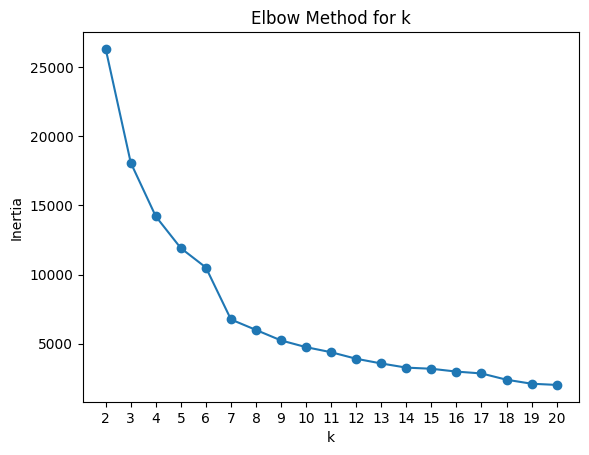

In [263]:
X = df[["longitude", "latitude"]]

inertias = []
K_range = range(2, 21)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_) #Inertia = sum of squared distances from each point to its cluster center.

plt.plot(K_range, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method for k")

plt.xticks(range(2, 21)) #showing x as 1 2 3 4 5 6 7 instead of 1, 2.5, 4
plt.show()

as we can see the optimal amount of Ks is at 7 

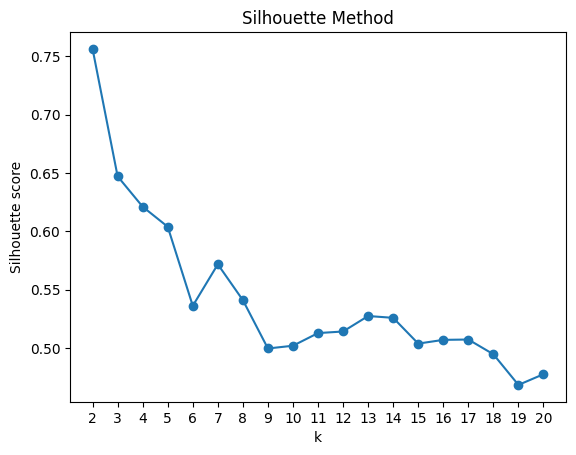

In [264]:
scores = []
K_range = range(2, 21)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.plot(K_range, scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Method")

plt.xticks(range(2, 21))
plt.show()

from the silhoutte scores we can see that a k of 7 makes the score spike (13 , 17 also spikes but has lower scores)

In [265]:
kmeans = KMeans(n_clusters=7, random_state=67) #we now use 7 clusters
df["region_cluster"] = kmeans.fit_predict(coords_scaled) # add a new column and insert the clusters of each x

In [266]:
region_df = pd.get_dummies(df["region_cluster"],"region", drop_first=True) #create dummies and drop first dummy var
region_df = region_df.astype(int)
df = pd.concat([df,region_df],axis=1)

df = df.drop(columns=["region_cluster", "longitude", "latitude"])


In [267]:
get_VIF_table(df,"median_house_value")

,Variables,VIF,R_squared
0,const,20.307,NaN
1,housing_median_age,1.226,0.011
2,median_income,1.322,0.474
3,ocean_prox_INLAND,1.907,0.235
4,ocean_prox_ISLAND,1.001,0.001
5,ocean_prox_NEAR_BAY,2.614,0.026
6,ocean_prox_NEAR_OCEAN,1.515,0.020
7,total_rooms_per_households,1.218,0.023
8,population_per_household,1.002,0.001
9,region_1,2.673,0.029


we now fixed the issue of Multicollinearity in lattitdue and longtitude variables, lets check our model again

In [268]:
model, X_test, y_train, y_test = fit_model(df)
print(model.summary())

Dataset:  (20433, 15)
Train:  (16346, 15)
Test:  (4087, 15)
                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     1849.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:28:40   Log-Likelihood:            -2.0610e+05
No. Observations:               16346   AIC:                         4.122e+05
Df Residuals:                   16331   BIC:                         4.124e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

Condition number reduced significantly from 2.37e+04 (interpreted 2.37 * 10^4) to 2.05e+03 (interpreted 2.05 * 10^3)

### **Interpretation of Summary Table**

**Coeff**: betaj values where the const variable is our beta0(intercept)

**Std.error**: standard error of beta j

**t**: are the statistic tests. If t > t_crit we reject null hypothesis where beta j is = 0 , meaning that our variable significantly contributes to the model

**p>|t|**: are the p values. If p value is < than our specified alpha, ex. 0.05 we reject null H, meaning that our variable significantly contributes to the model

**0.025 quantile** → lower bound of the 95% CI

**0.975 quantile** → upper bound of the 95% CI

It seems region 1 and region 6 do not significantly contribute to the model, as we can see from our p values, let us drop it before we continue

In [269]:
df = df.drop(columns=["region_1","region_6"])
model, X_test, y_train, y_test = fit_model(df)
print(model.summary())

Dataset:  (20433, 13)
Train:  (16346, 13)
Test:  (4087, 13)
                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     2157.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:28:40   Log-Likelihood:            -2.0611e+05
No. Observations:               16346   AIC:                         4.122e+05
Df Residuals:                   16333   BIC:                         4.123e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

### **Assumption 2: Linearity**


we can test by using residual plots (plotting standardized residuals against y_pred(fitted values))

In [270]:
fitted = model.fittedvalues
residuals = model.resid

In [271]:
standardized_resid = model.get_influence().resid_studentized_internal

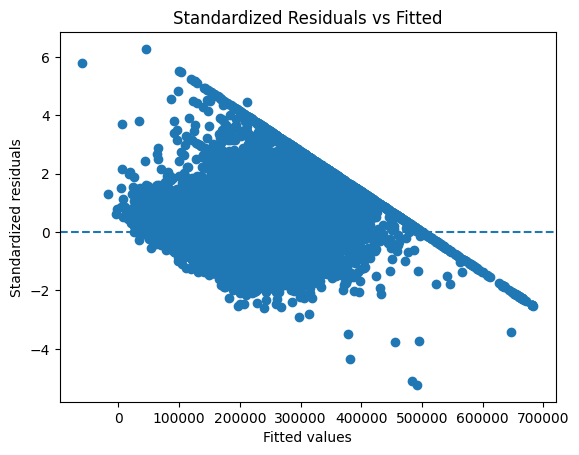

In [272]:
plt.scatter(fitted, standardized_resid)
plt.axhline(0, linestyle='--') #plot middle line
plt.xlabel("Fitted values")
plt.ylabel("Standardized residuals")
plt.title("Standardized Residuals vs Fitted")
plt.show()

There is a clear abnormal diagonal line (from top left to bottom right) showing errors are correlated with fitted values this violates our 4th and 1st assumption (residuals should float randomly around 0)

Upon researching about the collection of this dataset, I found out that when the Census Bureau collected the housing data, they imposed a reporting limit:
Any block group with a median_house_value(Yi) above $500,000 was simply recorded as $500,001 

In [273]:
print((df["median_house_value"] == 500001).sum())
print(df["median_house_value"].value_counts().sort_index().tail(10)) #print last 10 values and their count

958
median_house_value
497,400.000      1
497,600.000      1
498,400.000      1
498,600.000      1
498,700.000      1
498,800.000      1
499,000.000      1
499,100.000      1
500,000.000     27
500,001.000    958
Name: count, dtype: int64


The diagonal line occurs because of how residuals are computed mathematically(linear equation) where ei = Yi - Yi_pred  
as each X increasingly contributes, Yi_pred will Increase, and as Yi stays the same and Yi_pred increases (small number - large number)  
this will eventually lead to the residuals decreasing in a linear format.  
We can fix this by removing records that have a median_house_value > 500,000  

Dataset:  (19475, 13)
Train:  (15580, 13)
Test:  (3895, 13)


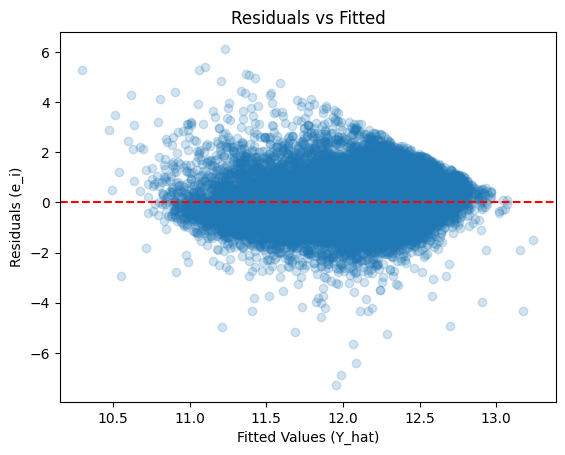

In [274]:
#copy dataframe
df_model = df[df["median_house_value"] <= 500000].copy()

# Overwrite in place and make log vals to gain clairity
df_model["median_house_value"] = np.log(df_model["median_house_value"])
df_model["median_income"] = np.log(df_model["median_income"])

# Refit
model, X_test, y_train, y_test = fit_model(df_model)

# Replot
fitted = model.fittedvalues
std_resid = model.get_influence().resid_studentized_internal #using statsmodel api lib to get studentized ei

plt.scatter(fitted, std_resid, alpha=0.2) # alpha reduces transparency
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Y_hat)")
plt.ylabel("Residuals (e_i)")
plt.title("Residuals vs Fitted")
plt.show()

After removing the diagonal line we can finally analyze our residual plot:  

1. We have complied with our 2nd linearity assumption (residuals are scattered randomly around 0) 
2. The plot looks like an inward funnel on both sides, indicating there is a inverse relationship between varience and fitted values which will violate our 4th assumption of Homoscedasticity(variance are same/constant)  
(if its an outward openning funnel pattern then it implies that the varience is an increasing function of Yi )

As fitted vals increase varience decreases(observations accumulate at same point at the **right**)  
As fitted vals decrease varience increases(observations accumulate at same point at the **left**)  

Since we are not sure if there is Heteroscedasticity occuring, let us use Breusch-Pagan's test to verify if there is.

### **Assumption 4: Homoscedasticity and Normality of errors**

In [275]:
#H0: Homoscedasticity is present.
#H0: Homoscedasticity is not present(heteroscedasticity occurs).

bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(
    model.resid,       # e_i residuals from training
    model.model.exog   # X matrix used during training
)

print(f"Breusch-Pagan Statistic: {bp_stat:.4f}") #4 decimal poins
print(f"P-value: {bp_pvalue:.4f}")
print(f"f-value: {f_stat:.4f}")
print(f"f p-value: {f_pvalue:.4f}")

if bp_pvalue < 0.05: #if p value < alpha(0.05) reject H0
    print("Heteroscedasticity is present")
else:
    print("Homoscedasticity holds")

Breusch-Pagan Statistic: 661.2283
P-value: 0.0000
f-value: 57.4966
f p-value: 0.0000
Heteroscedasticity is present


We know that heteroscedasticity is present but we dont know how much (the magnitude)  
since our residual plot showed mild signs of heteroscedasticity we should formally check if it mild or severe enough to fix it  
we can do this by finding the BP R-sqared(measures the percentage of variation in dependent variables )  

IF  

'<' 0.10  = Mild [OLS still reliable]  
0.10−0.30  = Moderate [consider fixing]  
'>' 0.30  = Severe [must fix]

In [276]:
# BP R-squared — practical magnitude of heteroscedasticity
bp_r2 = 1 - np.var(model.resid) / np.var(model.resid - model.fittedvalues)

# More direct way
aux_r2 = bp_stat / len(model.resid)
print(f"BP R-squared approximation: {aux_r2:.4f}")

BP R-squared approximation: 0.0424


Since our BP R-squared is < 0.10 , there is heteroscedasticity but very mild, and since in our former Residual plot had values scattered around mean = 0  
therefore we satisfy our 4th Assumption(Homoscedasticity and Normality Assumption) --> errors have a mean of 0 and constant varience

### **Assumption 3: Errors are Independent/ No Autocorrelation**

Finally We test if residuals are independent, one way we can do this is by **plotting residuals over their order**!  

Random noise around 0 --> No autocorrelation  
Slow wave/drifting up and down --> positive autocorrelation  
Rapid alternating above/below 0 --> negative autocorrelation  
Clusters of same-sign residuals --> autocorrelation by group  

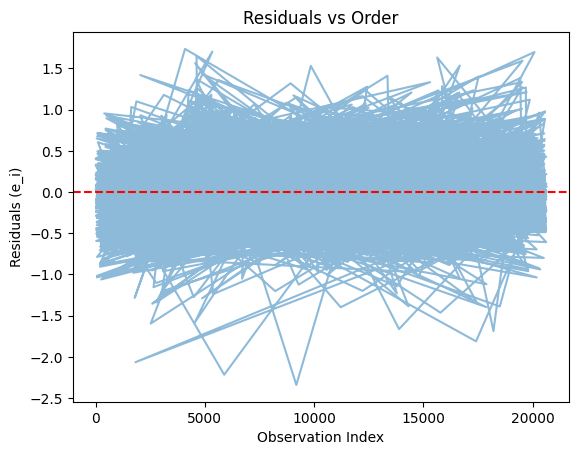

In [277]:
plt.plot(model.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Observation Index")
plt.ylabel("Residuals (e_i)")
plt.title("Residuals vs Order")
plt.show()

Plot indicates there is indeed no autocorrelation and All our assumptions have been satisfied. Next we test our model!

In [280]:
get_VIF_table(df,"median_house_value")

,Variables,VIF,R_squared
0,const,19.726,NaN
1,housing_median_age,1.214,0.011
2,median_income,1.321,0.474
3,ocean_prox_INLAND,1.797,0.235
4,ocean_prox_ISLAND,1.001,0.001
5,ocean_prox_NEAR_BAY,1.167,0.026
6,ocean_prox_NEAR_OCEAN,1.375,0.020
7,total_rooms_per_households,1.215,0.023
8,population_per_household,1.002,0.001
9,region_2,1.255,0.061
